##### Prepared by:
##### Kyle Owens
##### Gonzaga University
##### DATA-581
##### Summer 2026


# 1. Executive Summary (20 points)

This was primarily a learning and exploratory investigation. The data was probed for general correlations that would be interesting to further investigate. There are some simple numerical representations and some useful graphical representations after investigations progressed. The investigation revealed various combinations of species across the three islands with Adell across all three islands but Chinstrap and Gentoo penguins were present on only one island. The investigation also revealed that Gentoo penguins are statistically larger than Chinstrap and Adell which were of comparable mass on average.


# 2. Exploratory Data Analysis

Below are the exploratory techniques used to learn about this dataset

## Load and Clean Data

Load penguins dataset. Drop all rows that have missing values. 344 total rows in the raw data but 333 rows in the cleaned data dropping rows with null values in species, island, and sex.

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
# Load Data
penguins_raw = sns.load_dataset("penguins")
#raw_count = penguins_raw.count()
raw_count = len(penguins_raw)

# Clean data
penguins = penguins_raw.dropna(subset=['species', 'island', 'sex'])
clean_count = len(penguins)

print("Raw Dataframe Count: {}".format(raw_count))
print("Clean Dataframe Count: {}".format(clean_count))


Raw Dataframe Count: 344
Clean Dataframe Count: 333


## Summary Statistics

Below are the numerical explorations done to learn about the data

In [177]:
def line_print():
    print("="*40)

float_field_keys = [
    ("Bill Length(mm)", "bill_length_mm",),
    ("Bill Depth(mm)", "bill_depth_mm",),
    ("Flipper Length(mm)", "flipper_length_mm",),
    ("Body Mass(grams)", "body_mass_g",),
]

species_group = penguins.groupby("species")

math_ops = [
    "mean",
    "median",
    "std",
    "var",
    "min",
    "max",
]

for pretty_name, key in float_field_keys:
    line_print()
    line_print()
    print("Field: {}".format(pretty_name))
    line_print()
    print(species_group[key].agg(math_ops))
    line_print()

print()
for i in range(0,4):
    line_print()
print()

other_keys = [
    ("Island","island",),
    ("Species","species",),
    #("","",),
    #("","",),
]    

for name, key in other_keys:
    group_by_columns = ["sex"]
    group_by_columns.append(key)
    grouped_penguins = penguins.groupby(group_by_columns)
    line_print()
    print("Sex grouped by {}".format(pretty_name))
    line_print()
    print(grouped_penguins.count())
    line_print()

Field: Bill Length(mm)
                mean  median       std        var   min   max
species                                                      
Adelie     38.823973   38.85  2.662597   7.089421  32.1  46.0
Chinstrap  48.833824   49.55  3.339256  11.150630  40.9  58.0
Gentoo     47.568067   47.40  3.106116   9.647955  40.9  59.6
Field: Bill Depth(mm)
                mean  median       std       var   min   max
species                                                     
Adelie     18.347260   18.40  1.219338  1.486786  15.5  21.5
Chinstrap  18.420588   18.45  1.135395  1.289122  16.4  20.8
Gentoo     14.996639   15.00  0.985998  0.972192  13.1  17.3
Field: Flipper Length(mm)
                 mean  median       std        var    min    max
species                                                         
Adelie     190.102740   190.0  6.521825  42.534199  172.0  210.0
Chinstrap  195.823529   196.0  7.131894  50.863916  178.0  212.0
Gentoo     217.235294   216.0  6.585431  43.367896  20

## Categorical Comparison

Here is a large categorical comparison between all the different fields in the penguins dataset. I'm trying to visualize different relationships between the various fields based on species types as well which is the hue.

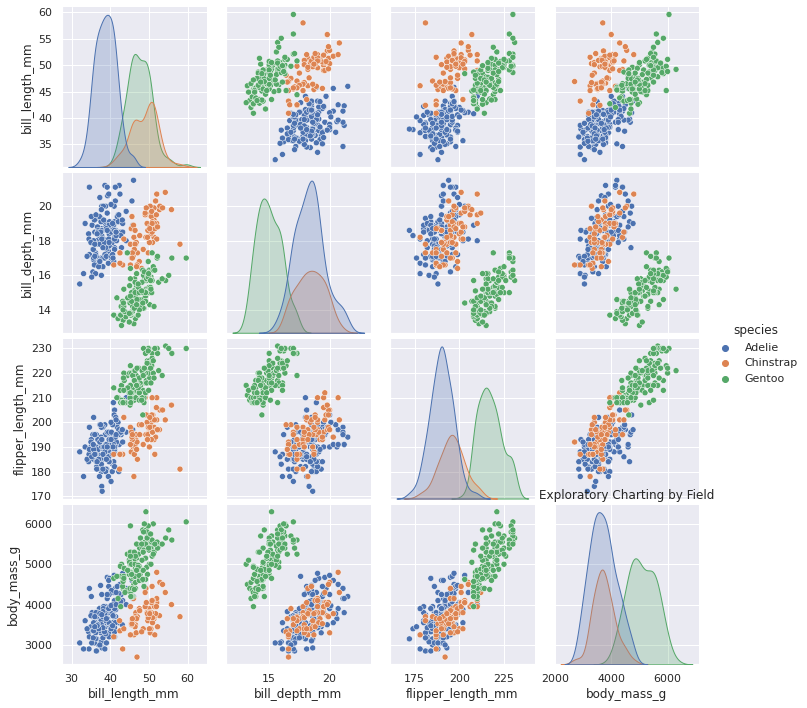

In [178]:
sns.pairplot(penguins, hue="species")
plt.title('Exploratory Charting by Field')
plt.show()

## Distribution chart

Here is a distribution chart showing the distribution of Flipper Length across each species. Adelle have the widest distribution with the largest total population while Gentoo have the smallest distribution but have the largest flippers on average.

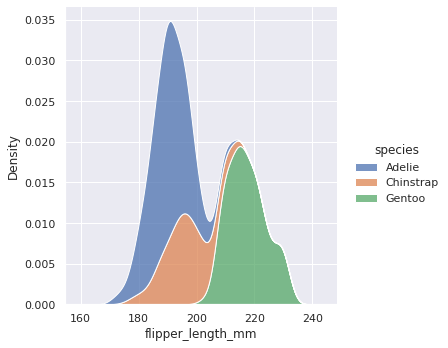

In [179]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack", kind="kde")
plt.show()

## Relationship Chart

Here is a chart showing the relations between penguin mass by sex across each population. In it you can see that Gentoo have the larger penguins in each sex while the Adell and Chinstrap are approximately the same size.

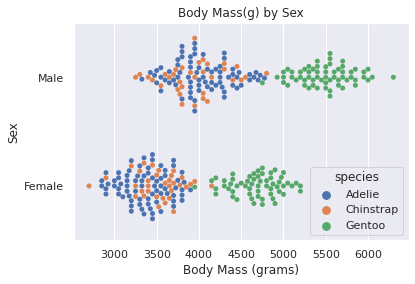

In [180]:
ax = sns.swarmplot(data=penguins, x="body_mass_g", y="sex", hue="species")
ax.set(ylabel="Sex", xlabel="Body Mass (grams)")
plt.title('Body Mass(g) by Sex')
plt.show()

## Other Interesting Graphical Representations

Below is swarm plot and a histogram plot with penguin mass grouped by sex and colored based on species. 

In this data, it shows that Adelle penguins are on all three islands while Gentoo is only on Biscoe and Chinstrap are only on Dream.

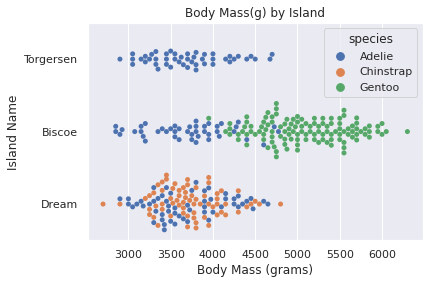

In [181]:
# Draw a categorical scatterplot to show each observation
ax = sns.swarmplot(data=penguins, x="body_mass_g", y="island", hue="species")
ax.set(ylabel="Island Name", xlabel="Body Mass (grams)")
plt.title('Body Mass(g) by Island')
plt.show()

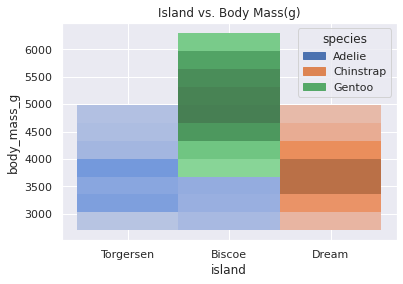

In [182]:
sns.histplot(x='island', y='body_mass_g', hue='species', data=penguins, multiple="stack")
plt.title('Island vs. Body Mass(g)')
ax.set(ylabel="Island Name", xlabel="Body Mass (grams)")
plt.show()

# 3. Ethics Concerns

### How can data visualizations unintentionally mislead audiences?

It can lead them to conclusions that aren't true. As saying goes, there are lies, damn lies, and statistics. Date Engineering and Data Science are simply a form of applied statistics against specific data sets with the end goal being understanding. They can misrepresent the truth in the exact same way statistics at large can misrepresent the truth.

### What responsibilities do analysts have when presenting results?

Analysts are responsible for understanding what their audience will take from the representation of the data they put forth because they are the only ones in the uniquely power position to understand the needs and biases of all the stakeholders at the table. These other stakeholders aren't stupid, but they aren't experts in data engineer and data science. As such, they don't know what they don't know. They will jump to conclusions based on sparse evidence. They will misinterpret data and think they understand. In short, they're human and it's part of the obligation of analysts to make sure that nobody is blind sided by the same issues that have plagued humanity for as long as we've had mathematical thought.

# 4. Analysis

### Which variable appears most influential in explaining the outcome?
Sex, Island Name, and Mass were all very interesting in exploring the clustering I saw in the first mutli-plot graph against metrics. The collection of graphs displayed in "Categorical Comparison" section was the most useful single graph in that it displayed a lot at low resolution but facilitated a very intuitive few for the data in a thumbnail sized dashboard. This helped me understand what other values to investigate very quickly.

### What insight would be most important to a decision maker?

Species distribution across islands was very interesting and would probably be used to inform any decision involving the cohort of penguins documented in this data set. The fact they all weren't on all islands is very interesting. I also find the mass of the penguins interesting, especially when grouped by island, or by sex. What ended up delivering information the quickest was comparing by a pair of axes like mass and sex, or island and sex. Using scatter plots you understand the distribution easily and intuitively which was very useful for further investigation and would almost certainly be a useful phenomenon for a decision maker.

### Which visualization best communicates your strongest finding and why?

The graphs in "Other Interesting Graphical Representations" section convey the species distribution across the island trivially. The graph in the "Distribution Chart" section clearly demonstrates the size distributions as well and how the species of penguins relate to each other by mass.

### What limitations exist in your analysis?

I feel like the rigor of my numerival analysis was formulaic and poorly explained.

### What additional data would improve your conclusions?

Sample size would help a lot at increasing confidence though this data was reasonable sized for a wildlife sampling. One thing that would help greatly would be the total population size of the various species such that we could better understand exactly how representational we could determine our mathematical analysis is. If it's 1% of the population, we'd be able to trust it much more than if it was 0.01% of the population. 